In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
data = pd.read_csv("ToyotaCorolla.csv", index_col="Id")
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(data.head())
print(data.shape)

                                            Model  Price  Age_08_04  \
Id                                                                    
1   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
2   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
3   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
4   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
5     TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

    Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color   Color  Automatic  \
Id                                                                           
1          10      2002  46986    Diesel  90          1    Blue          0   
2          10      2002  72937    Diesel  90          1  Silver          0   
3           9      2002  41711    Diesel  90          1    Blue          0   
4           7      2002  48000    Diesel  90          0   Black          0   
5           3      2002  38500    

## Пункты 2, 3 и 4

Как вы предобрабатывали данные?


Провёл проверку на пропуски, просмотрел типы данных


Что вы поняли, проведя EDA?


В датасете нет пропущенных значений (все 1436 строк заполнены), средняя цена автомобиля составляет около 10 730 евро, большинство машин имеют возраст около 56 месяцев и пробег 68,5 тыс. км.

Целевая переменная (Price) имеет значительный разброс (от 4350 до 32 500)

In [2]:
print(data.describe())
print(data.info())
print(data.isnull().sum().to_string())

              Price    Age_08_04    Mfg_Month     Mfg_Year             KM  \
count   1436.000000  1436.000000  1436.000000  1436.000000    1436.000000   
mean   10730.824513    55.947075     5.548747  1999.625348   68533.259749   
std     3626.964585    18.599988     3.354085     1.540722   37506.448872   
min     4350.000000     1.000000     1.000000  1998.000000       1.000000   
25%     8450.000000    44.000000     3.000000  1998.000000   43000.000000   
50%     9900.000000    61.000000     5.000000  1999.000000   63389.500000   
75%    11950.000000    70.000000     8.000000  2001.000000   87020.750000   
max    32500.000000    80.000000    12.000000  2004.000000  243000.000000   

                HP    Met_Color    Automatic           CC        Doors  \
count  1436.000000  1436.000000  1436.000000   1436.00000  1436.000000   
mean    101.502089     0.674791     0.055710   1576.85585     4.033426   
std      14.981080     0.468616     0.229441    424.38677     0.952677   
min      6

In [3]:
X = data.drop(columns=["Price"])
y = data["Price"]

In [4]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(cat_cols)
for col in cat_cols:
    print(col, X[col].nunique())
print(X["Color"].unique())

num_cols = X.select_dtypes(include=["int64"]).columns.tolist()

['Model', 'Fuel_Type', 'Color']
Model 319
Fuel_Type 3
Color 10
['Blue' 'Silver' 'Black' 'White' 'Grey' 'Red' 'Green' 'Yellow' 'Violet'
 'Beige']


In [5]:
print(X["Cylinders"].nunique())

1


In [6]:
num_unique = {}
for col in X.columns:
    num_unique[col] = X[col].nunique()
    

for key, item in sorted(num_unique.items(), key=lambda x: x[1]):
    print(key, item)

Cylinders 1
Met_Color 2
Automatic 2
Mfr_Guarantee 2
BOVAG_Guarantee 2
ABS 2
Airbag_1 2
Airbag_2 2
Airco 2
Automatic_airco 2
Boardcomputer 2
CD_Player 2
Central_Lock 2
Powered_Windows 2
Power_Steering 2
Radio 2
Mistlamps 2
Sport_Model 2
Backseat_Divider 2
Metallic_Rim 2
Radio_cassette 2
Parking_Assistant 2
Tow_Bar 2
Fuel_Type 3
Doors 4
Gears 4
Mfg_Year 7
Guarantee_Period 9
Color 10
Mfg_Month 12
HP 12
CC 13
Quarterly_Tax 13
Weight 59
Age_08_04 77
Model 319
KM 1263


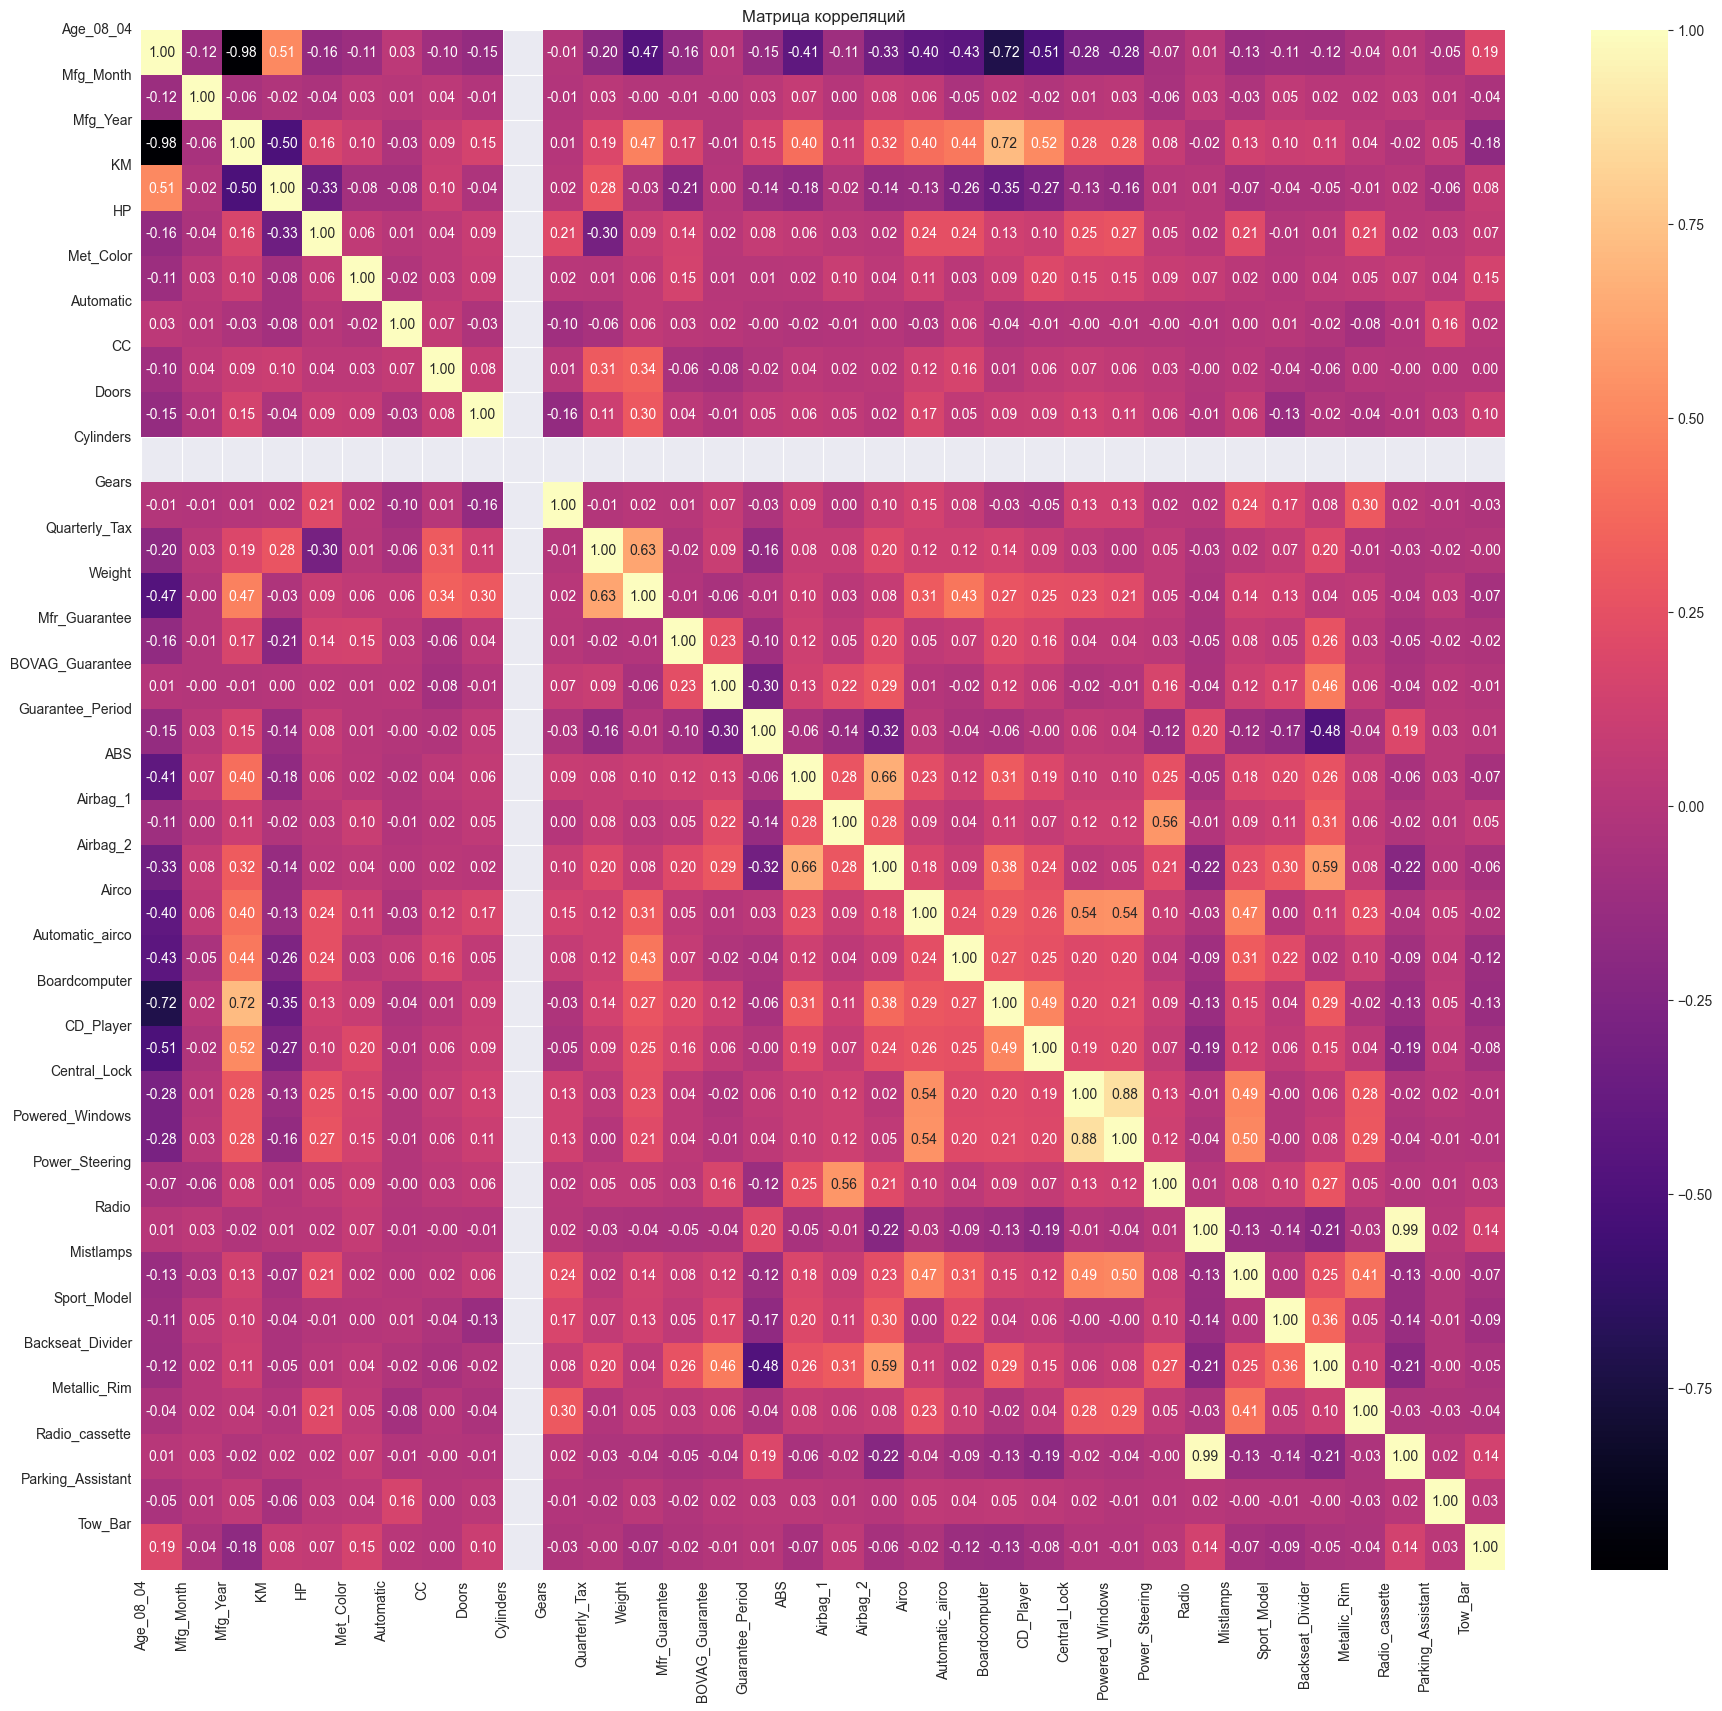

In [7]:
corr = X.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

In [8]:
X.drop(columns=["Cylinders", "Mfg_Year", "Model", "Radio_cassette"], inplace=True)

In [9]:
cols_to_encode = ["Fuel_Type", "Gears", "Doors", "Color", "Mfg_Month"]
cols_to_scale = ['Age_08_04', 'KM', 'HP', 'Quarterly_Tax', 'Weight']

In [10]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_to_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cols_to_encode)
    ],
    remainder="passthrough"
)

In [11]:
preprocessor.fit(X)
X_transformed = preprocessor.transform(X)
column_names = preprocessor.get_feature_names_out()
X_transformed = pd.DataFrame(X_transformed, columns=column_names, index=X.index)


Как вы работали с признаками?

построил heatmap корреляций, посмотрел уникальные значения признаков, прочитал описания признаков с сайта датасета


Какие признаки вы добавили / изменили и почему?

Добавил one hot encoding признаки для категориальных признаков и для тех признаков которые были закодированы числами в оригинальном датасете
Проскейлил числовые признаки потому что у них разные размерности

Какие признаки вы удалили и почему?

Удалил название модели, такак как их слишком много для такого датасета, если бы данных было больше можно было бы добавить признаки принадлежности самым популярным моделям, убрал так же бесполезные признаки (одно значение, либо почти прямая кореляция с другими признаками)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=28)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_to_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cols_to_encode)
    ],
    remainder="passthrough"
)
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
column_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(X_train_transformed, columns=column_names, index=X_train.index)
X_test_transformed = preprocessor.transform(X_test)
column_names = preprocessor.get_feature_names_out()
X_test_transformed = pd.DataFrame(X_test_transformed, columns=column_names, index=X_test.index)

Как именно вы разделили выборку?

С помощью train test split с 1/3 выборки отведённой под тест

Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

Мы разделяем выборку на тест и трейн чтобы не завышать рещультат модели и понимать как она будет вести себя на новых, не известных ей данных, как было бы в реальном мире

## Пункты 5 и 6

In [13]:

base_model = LinearRegression()
base_model.fit(X_train_transformed, y_train)
y_preds_base_model = base_model.predict(X_test_transformed)
print("mean absolute error", mean_absolute_error(y_test, y_preds_base_model))
print("mean squared error", mean_squared_error(y_test, y_preds_base_model))
print("mean_absolute_percentage_error", mean_absolute_percentage_error(y_test, y_preds_base_model))
print("r2 score", r2_score(y_test, y_preds_base_model))

mean absolute error 857.3739809096095
mean squared error 1250591.0534462524
mean_absolute_percentage_error 0.085770550298864
r2 score 0.8964653514460414


In [14]:
param_grid_ridge = {
    "alpha": np.logspace(0.001, 1000, 200)
}

grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

grid_ridge.fit(X_train_transformed, y_train)

print(grid_ridge.best_params_)
ridge_alpha = grid_ridge.best_params_["alpha"]

ridge_model = Ridge(alpha=ridge_alpha)
ridge_model.fit(X_train_transformed, y_train)
y_preds_ridge = ridge_model.predict(X_test_transformed)
print("mean absolute error", mean_absolute_error(y_test, y_preds_ridge))
print("mean squared error", mean_squared_error(y_test, y_preds_ridge))
print("mean_absolute_percentage_error", mean_absolute_percentage_error(y_test, y_preds_ridge))
print("r2 score", r2_score(y_test, y_preds_ridge))

{'alpha': np.float64(1.0023052380778996)}
mean absolute error 848.5689212213844
mean squared error 1231259.8245769814
mean_absolute_percentage_error 0.08511227196376206
r2 score 0.8980657562958769


In [15]:
param_grid_lasso = {
    "alpha": np.logspace(0.001, 1000, 200)
}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid_lasso, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

grid_lasso.fit(X_train_transformed, y_train)

print(grid_lasso.best_params_)
lasso_alpha = grid_lasso.best_params_["alpha"]
lasso_model = Lasso(alpha=lasso_alpha)
lasso_model.fit(X_train_transformed, y_train)
y_preds_lasso = lasso_model.predict(X_test_transformed)
print("mean absolute error", mean_absolute_error(y_test, y_preds_lasso))
print("mean squared error", mean_squared_error(y_test, y_preds_lasso))
print("mean_absolute_percentage_error", mean_absolute_percentage_error(y_test, y_preds_lasso))
print("r2 score", r2_score(y_test, y_preds_lasso))

{'alpha': np.float64(1.0023052380778996)}
mean absolute error 844.2569732726381
mean squared error 1227805.8036373355
mean_absolute_percentage_error 0.08462830967841559
r2 score 0.8983517097601199


обычная линейная регрессия обучилась моментально, а lasso и ridge обучались дольше из-за поиска гиперпараметра, но lasso обучилась кратно быстрее, этому объяснения не могу придумать

1. Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?).

mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error 

MAE наглядно показывает среднюю ошибку в денежных еденицах, MSE чувствительна к выбросам, R2 показывает долю объясненной дисперсии, MAPE показывает ошибку относительно масштаба целевой переменной

2. На какой части выборки вы считали метрики?

На тестовой

3. Какая модель по итогу справилась лучше?

Lasso справилась лучше всех по всем метрикам, но разница оцень не существенна


4. Насколько хорошие получились результаты?

показатель mean_absolute_percentage_error = 0.08462830967841559 говорит о том что в масштабе наших данных модель совершает очень маленькие ошибки

5. Чем докажете, что ваша модель не переобучилась?

высокий рещультат на тестовой выборке, которую модель не видела при обучении, кодировании данных и скейлинге 